# Multi-Agent Deep Research for Cat Nutrition and Obesity

Deep research is not one enormous prompt. It is a composition of familiar patterns:

```text
scope -> delegate -> search -> verify -> write -> audit -> evaluate
```

In this notebook, every reasoning actor is built with LangChain's `create_agent`.
A small LangGraph workflow controls the lifecycle, parallel-friendly delegation,
optional human clarification, persistence, and deterministic checks.

The worked example asks:

> What does current evidence say about preventing and safely managing obesity in adult indoor cats?

This is an educational research workflow. It does not diagnose an animal or create
an individualized feeding or weight-loss plan.

## Learning Outcomes

By the end of this notebook, you will be able to:

- Explain when multiple agents improve context isolation and role specialization.
- Build named `create_agent` workers and expose them as high-level tools.
- Use structured outputs as contracts between research stages.
- Combine agentic loops with a deterministic LangGraph workflow.
- Pause and resume a workflow with `interrupt()` and `Command(resume=...)`.
- Track source URLs through research, verification, writing, and citation auditing.
- Reason about research quality, latency, and API cost as explicit design tradeoffs.


## Table of Contents

- **Breakout Room #1: Specialized Agents and Delegation**
  - Task 1: Environment Setup
  - Task 2: Define Typed Handoff Contracts
  - Task 3: Configure Tavily Search and Extract
  - Task 4: Build Specialized Research Workers
  - Task 5: Wrap Workers as Supervisor Tools
  - Task 6: Build the Research Supervisor
  - Activity #1: Add a New Specialist
- **Breakout Room #2: End-to-End Deep Research Workflow**
  - Task 7: Build the Scoper and Clarification Path
  - Task 8: Build Verification, Writing, and Evaluation Agents
  - Task 9: Define LangGraph State and Nodes
  - Task 10: Compile, Visualize, and Stream the Workflow
  - Task 11: Audit Citations Deterministically
  - Task 12: Run the Full Deep Research System
  - Activity #2: Compare Research Depth and Cost
  - Advanced Build: Add a Local-Corpus Specialist


---
# Breakout Room #1
## Specialized Agents and Delegation

A multi-agent system is useful when independent actors need different prompts,
tools, context, or optimization targets.

Our supervisor does not search the web directly. It delegates bounded research
tasks to workers and receives compact, typed findings. This keeps low-level search
traces out of the supervisor's context.


## Task 1: Environment Setup

From the `04_Multi_Agent_Systems` folder:

```bash
uv sync
```

Then select the environment created by uv as this notebook's kernel.

Required accounts:

- OpenAI API
- Tavily API

LangSmith tracing is optional but strongly recommended for inspecting nested agents.


### Imports


In [1]:
from __future__ import annotations

import json
import os
import re
from datetime import date
from getpass import getpass
from typing import Literal, TypedDict
from urllib.parse import urlsplit, urlunsplit

from IPython.display import Image, Markdown, display
from pydantic import BaseModel, Field

from langchain.agents import create_agent
from langchain.agents.middleware import (
    ModelCallLimitMiddleware,
    ToolCallLimitMiddleware,
)
from langchain.messages import ToolMessage
from langchain.tools import tool
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilyExtract, TavilySearch

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt


### API Keys, Models, and Research Budgets

The environment variables make the notebook easy to tune without editing code.
Research depth is an application policy, not a mysterious property of the model.

`AIM_SEARCH_CALL_LIMIT` limits Tavily searches per worker invocation.
`AIM_WORKER_MODEL_CALL_LIMIT` bounds each worker's ReAct loop.


In [2]:
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("OpenAI API Key: ")

if not os.environ.get("TAVILY_API_KEY"):
    os.environ["TAVILY_API_KEY"] = getpass("Tavily API Key: ")

os.environ.setdefault(
    "LANGSMITH_PROJECT",
    "aim-session-4-multi-agent-deep-research",
)

TODAY = date.today().isoformat()
CHAT_MODEL_NAME = os.environ.get("AIM_CHAT_MODEL", "gpt-5.4-mini")
WRITER_MODEL_NAME = os.environ.get("AIM_WRITER_MODEL", CHAT_MODEL_NAME)
SEARCH_DEPTH = os.environ.get("AIM_SEARCH_DEPTH", "advanced")
SEARCH_CALL_LIMIT = int(os.environ.get("AIM_SEARCH_CALL_LIMIT", "3"))
EXTRACT_CALL_LIMIT = int(os.environ.get("AIM_EXTRACT_CALL_LIMIT", "2"))
WORKER_MODEL_CALL_LIMIT = int(
    os.environ.get("AIM_WORKER_MODEL_CALL_LIMIT", "8")
)

llm = ChatOpenAI(model=CHAT_MODEL_NAME)
writer_llm = ChatOpenAI(model=WRITER_MODEL_NAME)

print(f"Date: {TODAY}")
print(f"General model: {CHAT_MODEL_NAME}")
print(f"Writer model: {WRITER_MODEL_NAME}")
print(f"Search depth: {SEARCH_DEPTH}")
print(f"Search calls per worker: {SEARCH_CALL_LIMIT}")
print(f"LangSmith tracing: {os.environ.get('LANGSMITH_TRACING', 'false')}")


Date: 2026-06-11
General model: gpt-5.4-mini
Writer model: gpt-5.4-mini
Search depth: advanced
Search calls per worker: 3
LangSmith tracing: true


## Task 2: Define Typed Handoff Contracts

Free-form prose is difficult to validate and pass between application stages.
Pydantic models make the handoff contracts explicit.

Notice that source URLs are first-class data. The report writer will not be allowed
to invent a new source that did not survive verification.


In [3]:
SpecialistName = Literal["guidelines", "evidence"]
ConfidenceLevel = Literal["high", "medium", "low"]


class ResearchTask(BaseModel):
    task_id: str = Field(description="Stable short identifier such as task-1")
    question: str = Field(description="Focused research question for one worker")
    specialist: SpecialistName
    rationale: str


class ResearchBrief(BaseModel):
    title: str
    objective: str
    audience: str
    scope_in: list[str]
    scope_out: list[str]
    safety_constraints: list[str]
    tasks: list[ResearchTask] = Field(min_length=3, max_length=3)


class ScopeDecision(BaseModel):
    needs_clarification: bool
    clarification_question: str | None = None
    assumptions: list[str] = Field(default_factory=list)
    brief: ResearchBrief | None = None


class SourceRecord(BaseModel):
    url: str
    title: str
    publisher: str
    published_date: str | None = None
    source_type: Literal[
        "guideline",
        "peer_reviewed",
        "government",
        "university",
        "professional_org",
        "other",
    ]
    authority_reason: str
    relevant_excerpt: str
    accessed_on: str


class ClaimRecord(BaseModel):
    claim: str
    source_urls: list[str] = Field(min_length=1)
    confidence: ConfidenceLevel
    caveat: str


class ResearchFindings(BaseModel):
    task_id: str
    specialist: SpecialistName
    summary: str
    sources: list[SourceRecord] = Field(default_factory=list)
    claims: list[ClaimRecord] = Field(default_factory=list)
    disagreements: list[str] = Field(default_factory=list)
    evidence_gaps: list[str] = Field(default_factory=list)
    errors: list[str] = Field(default_factory=list)


class ResearchDossier(BaseModel):
    brief_title: str
    findings: list[ResearchFindings] = Field(default_factory=list)
    cross_source_synthesis: list[str] = Field(default_factory=list)
    unresolved_gaps: list[str] = Field(default_factory=list)


class RejectedSource(BaseModel):
    url: str
    reason: str


class VerificationReport(BaseModel):
    approved_sources: list[SourceRecord] = Field(default_factory=list)
    rejected_sources: list[RejectedSource] = Field(default_factory=list)
    verified_claims: list[ClaimRecord] = Field(default_factory=list)
    unsupported_claims: list[str] = Field(default_factory=list)
    disagreements: list[str] = Field(default_factory=list)
    evidence_gaps: list[str] = Field(default_factory=list)
    verification_summary: str


class FinalReport(BaseModel):
    title: str
    executive_summary: str
    report_markdown: str
    limitations: list[str]
    medical_safety_note: str
    citations: list[str] = Field(
        description="Ordered list of source URLs cited in report_markdown"
    )


class CitationAudit(BaseModel):
    cited_urls: list[str]
    unknown_urls: list[str]
    duplicate_urls: list[str]
    approved_but_uncited: list[str]
    missing_marker_numbers: list[int]
    passed: bool


class ReportEvaluation(BaseModel):
    coverage: int = Field(ge=1, le=5)
    synthesis: int = Field(ge=1, le=5)
    source_quality: int = Field(ge=1, le=5)
    citation_integrity: int = Field(ge=1, le=5)
    uncertainty_handling: int = Field(ge=1, le=5)
    medical_safety: int = Field(ge=1, le=5)
    strengths: list[str]
    improvements: list[str]
    passed: bool


#### ❓Question #1

Why is a typed handoff safer than asking each agent to return "a useful summary"?
Which fields are application guarantees, and which still depend on model judgment?

##### ✅ Answer:

**Why a typed handoff is safer.** A free-form "useful summary" gives the next stage
nothing it can validate. The downstream code has to re-parse prose, hope the model
included URLs, hope it labeled uncertainty, and hope it did not silently merge
contradictory studies. With Pydantic models on the boundary:

- The runtime fails fast on shape errors (`min_length=1` source URLs per claim,
  exactly three tasks per brief, enum-bounded `specialist`, `confidence`, and
  `source_type`) instead of letting bad data leak into the writer.
- The schema makes provenance a first-class field (`SourceRecord.url`,
  `ClaimRecord.source_urls`), which is what lets `sanitize_findings` and the
  citation auditor enforce that the writer cannot cite a URL the worker never
  observed.
- Each stage has a narrow contract, so we can unit-test the auditor and the
  sanitizers with synthetic fixtures (as Task 11 does) without invoking a model.
- Structured outputs cap context growth: the supervisor sees one compact JSON
  per worker, not the worker's entire ReAct transcript.

**Application guarantees (enforced by code regardless of model behavior).**

- Schema shape and required fields (`brief.tasks` is exactly 3,
  `ClaimRecord.source_urls` has at least one entry, every `specialist` value is in
  the `Literal`, every score is in `[1, 5]`).
- URL provenance: `sanitize_findings` / `sanitize_dossier` / `sanitize_verification`
  drop any source URL that did not appear in the worker's own
  `tavily_search` / `tavily_extract` tool messages, and drop any claim whose URLs
  do not trace to an approved source.
- Missing-task accounting: if a delegated task returns no findings,
  `sanitize_dossier` records it as an unresolved gap instead of silently dropping
  it.
- Citation integrity: `audit_report_citations` deterministically checks that the
  writer's `[n]` markers and final URL list match the verifier-approved sources.

**Still depends on model judgment.**

- The *content* of free-text fields: `summary`, `authority_reason`,
  `relevant_excerpt`, `rationale`, `caveat`, `disagreements`, `evidence_gaps`,
  `verification_summary`, `report_markdown`, `executive_summary`,
  `medical_safety_note`, `strengths`, `improvements`.
- Subjective categorical fields whose value the model chooses: `confidence`
  (`high`/`medium`/`low`), `source_type` (whether a page truly is a "guideline"
  vs "professional_org"), and the evaluator's 1-5 scores.
- Whether a claim is genuinely supported by the cited excerpt (provenance proves
  the URL was visited; it does not prove the URL supports the claim — that is
  what the separate verifier stage is for).
- Whether the scoper's three tasks are actually well-decomposed and independent.

So the schema gives us *structural* and *provenance* guarantees; the verifier,
auditor, and evaluator stages are how we add additional checks on top of the
*semantic* fields that remain model-dependent.

## Task 3: Configure Tavily Search and Extract

Search discovers candidate sources. Extract reads selected pages more deeply.
We deliberately do not use Tavily's Research API because the goal is to build the
multi-agent research behavior ourselves.


In [4]:
tavily_search = TavilySearch(
    max_results=5,
    topic="general",
    search_depth=SEARCH_DEPTH,
    include_answer=False,
    include_raw_content=False,
)

tavily_extract = TavilyExtract(
    extract_depth="advanced",
    format="markdown",
    chunks_per_source=3,
)

print(tavily_search.name)
print(tavily_extract.name)


tavily_search
tavily_extract


The search and extraction tools return URLs in tool messages. We will retain only
source URLs that were actually observed in those tool results. This does not prove
a claim is correct, but it prevents an agent from adding an entirely unobserved URL
to the source ledger.


In [5]:
URL_PATTERN = re.compile(r"https?://[^\s\]\[()<>{}\"']+")


def normalize_url(url: str) -> str:
    '''Normalize a URL for deterministic ledger comparison.'''
    cleaned = url.strip().rstrip(".,;:!?)")
    parts = urlsplit(cleaned)
    path = parts.path.rstrip("/") or "/"
    return urlunsplit(
        (
            parts.scheme.lower(),
            parts.netloc.lower(),
            path,
            parts.query,
            "",
        )
    )


def urls_in_value(value: object) -> set[str]:
    '''Extract normalized URLs from strings or JSON-like tool content.'''
    text = value if isinstance(value, str) else json.dumps(value, default=str)
    return {normalize_url(match) for match in URL_PATTERN.findall(text)}


def observed_tool_urls(agent_result: dict) -> set[str]:
    observed: set[str] = set()
    for message in agent_result.get("messages", []):
        if isinstance(message, ToolMessage):
            observed.update(urls_in_value(message.content))
    return observed


def sanitize_findings(
    findings: ResearchFindings,
    observed_urls: set[str],
) -> ResearchFindings:
    '''Drop sources and claims that cannot be traced to worker tool output.'''
    approved_sources = [
        source
        for source in findings.sources
        if normalize_url(source.url) in observed_urls
    ]
    approved_urls = {normalize_url(source.url) for source in approved_sources}

    approved_claims = []
    dropped_claims = []
    for claim in findings.claims:
        traced_urls = [
            url
            for url in claim.source_urls
            if normalize_url(url) in approved_urls
        ]
        if traced_urls:
            approved_claims.append(
                claim.model_copy(update={"source_urls": traced_urls})
            )
        else:
            dropped_claims.append(
                f"Untraced claim removed before supervision: {claim.claim}"
            )

    errors = list(findings.errors)
    if findings.sources and not approved_sources:
        errors.append(
            "The worker returned sources, but none of their URLs appeared "
            "in its search or extraction tool messages."
        )

    return findings.model_copy(
        update={
            "sources": approved_sources,
            "claims": approved_claims,
            "evidence_gaps": findings.evidence_gaps + dropped_claims,
            "errors": errors,
        }
    )


def sanitize_dossier(
    dossier: ResearchDossier,
    brief: ResearchBrief,
    observed_urls: set[str],
) -> ResearchDossier:
    '''Enforce worker URL provenance and record missing delegated tasks.'''
    task_by_id = {task.task_id: task for task in brief.tasks}
    sanitized_findings = []
    unexpected_findings = []
    for finding in dossier.findings:
        task = task_by_id.get(finding.task_id)
        if task is None:
            unexpected_findings.append(
                f"Unexpected findings returned for {finding.task_id}."
            )
            continue
        normalized_finding = finding.model_copy(
            update={"specialist": task.specialist}
        )
        sanitized_findings.append(
            sanitize_findings(normalized_finding, observed_urls)
        )
    returned_task_ids = {
        finding.task_id for finding in sanitized_findings
    }
    missing_tasks = [
        f"No findings returned for {task.task_id}: {task.question}"
        for task in brief.tasks
        if task.task_id not in returned_task_ids
    ]
    return dossier.model_copy(
        update={
            "brief_title": brief.title,
            "findings": sanitized_findings,
            "unresolved_gaps": (
                dossier.unresolved_gaps
                + unexpected_findings
                + missing_tasks
            ),
        }
    )


def sanitize_verification(
    verification: VerificationReport,
    observed_urls: set[str],
) -> VerificationReport:
    '''Keep only sources and claims traced to verifier tool output.'''
    approved_sources = [
        source
        for source in verification.approved_sources
        if normalize_url(source.url) in observed_urls
    ]
    approved_urls = {
        normalize_url(source.url) for source in approved_sources
    }
    verified_claims = []
    unsupported_claims = list(verification.unsupported_claims)
    for claim in verification.verified_claims:
        traced_urls = [
            url
            for url in claim.source_urls
            if normalize_url(url) in approved_urls
        ]
        if traced_urls:
            verified_claims.append(
                claim.model_copy(update={"source_urls": traced_urls})
            )
        else:
            unsupported_claims.append(
                f"Untraced verifier claim removed: {claim.claim}"
            )

    evidence_gaps = list(verification.evidence_gaps)
    if verification.approved_sources and not approved_sources:
        evidence_gaps.append(
            "The verifier approved sources, but none appeared in its tool output."
        )

    return verification.model_copy(
        update={
            "approved_sources": approved_sources,
            "verified_claims": verified_claims,
            "unsupported_claims": unsupported_claims,
            "evidence_gaps": evidence_gaps,
        }
    )


## Task 4: Build Specialized Research Workers

Both workers use the same model and tools, but they have different search priorities
and evaluation criteria.

- The **guideline researcher** prioritizes professional and public-health guidance.
- The **evidence researcher** prioritizes peer-reviewed studies and actively tests
  common nutrition claims.

The workers return `ResearchFindings`, not final prose for the user.


In [6]:
def worker_middleware():
    '''Create fresh operational limits for one research agent.'''
    return [
        ModelCallLimitMiddleware(
            run_limit=WORKER_MODEL_CALL_LIMIT,
            exit_behavior="end",
        ),
        ToolCallLimitMiddleware(
            tool_name=tavily_search.name,
            run_limit=SEARCH_CALL_LIMIT,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=tavily_extract.name,
            run_limit=EXTRACT_CALL_LIMIT,
            exit_behavior="continue",
        ),
    ]


GUIDELINE_RESEARCHER_PROMPT = f'''
You are the guideline specialist in a multi-agent veterinary research system.
Today's date is {TODAY}.

Research only the assigned task. Prioritize primary or authoritative sources:
AAFP, AAHA, WSAVA, AVMA, government agencies, veterinary schools, and recognized
veterinary nutrition organizations. Search before making factual claims. Extract
promising pages when snippets are not enough.

Return exactly the ResearchFindings schema. Every source URL and every claim URL
must come from a search or extraction tool result in this run. Explain why each
source is authoritative. Record disagreement and missing evidence. Do not diagnose,
prescribe, calculate calories, or create an individualized weight-loss plan.
Your final response is the only information the supervisor receives.
'''

EVIDENCE_RESEARCHER_PROMPT = f'''
You are the evidence specialist in a multi-agent veterinary research system.
Today's date is {TODAY}.

Research only the assigned task. Prioritize peer-reviewed studies, systematic
reviews, consensus statements, university sources, and primary publications.
Challenge broad claims about wet versus dry food, meal frequency, activity,
energy restriction, body-condition scoring, and safe rates of feline weight loss.
Distinguish association from causation and guidelines from controlled evidence.
Search before making factual claims and extract promising pages when needed.

Return exactly the ResearchFindings schema. Every source URL and every claim URL
must come from a search or extraction tool result in this run. Preserve uncertainty,
conflicting findings, study limitations, and unanswered questions. Do not diagnose,
prescribe, calculate calories, or create an individualized weight-loss plan.
Your final response is the only information the supervisor receives.
'''

guideline_researcher = create_agent(
    model=llm,
    tools=[tavily_search, tavily_extract],
    system_prompt=GUIDELINE_RESEARCHER_PROMPT,
    middleware=worker_middleware(),
    response_format=ResearchFindings,
    name="guideline_researcher",
)

evidence_researcher = create_agent(
    model=llm,
    tools=[tavily_search, tavily_extract],
    system_prompt=EVIDENCE_RESEARCHER_PROMPT,
    middleware=worker_middleware(),
    response_format=ResearchFindings,
    name="evidence_researcher",
)

print("Created named guideline and evidence research agents.")


Created named guideline and evidence research agents.


## Task 5: Wrap Workers as Supervisor Tools

This is the central subagent pattern:

```text
supervisor -> high-level worker tool -> create_agent worker -> Tavily tools
```

The supervisor sees one compact JSON result per worker call. It does not receive the
worker's entire message history.

The wrappers also turn worker failures into explicit gaps so one failed research
stream does not erase successful work from another stream.


In [7]:
def failed_findings(
    task: ResearchTask,
    specialist: SpecialistName,
    error: Exception,
) -> ResearchFindings:
    return ResearchFindings(
        task_id=task.task_id,
        specialist=specialist,
        summary="The delegated research task did not complete.",
        evidence_gaps=[task.question],
        errors=[f"{type(error).__name__}: {error}"],
    )


async def run_worker(
    agent,
    task_json: str,
    specialist: SpecialistName,
) -> ResearchFindings:
    try:
        task = ResearchTask.model_validate_json(task_json)
    except Exception as exc:
        return ResearchFindings(
            task_id="invalid-task",
            specialist=specialist,
            summary="The supervisor supplied an invalid research task.",
            evidence_gaps=["The delegated task could not be parsed."],
            errors=[f"{type(exc).__name__}: {exc}"],
        )

    try:
        result = await agent.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": (
                            "Complete this delegated research task and return "
                            f"the required structured findings:\n{task_json}"
                        ),
                    }
                ]
            }
        )
        findings = ResearchFindings.model_validate(
            result["structured_response"]
        )
        findings = findings.model_copy(
            update={
                "task_id": task.task_id,
                "specialist": specialist,
            }
        )
        return sanitize_findings(
            findings,
            observed_tool_urls(result),
        )
    except Exception as exc:
        return failed_findings(task, specialist, exc)


@tool(
    "research_guidelines",
    description=(
        "Delegate one structured ResearchTask to the veterinary guideline "
        "specialist. Input must be the task's JSON representation."
    ),
)
async def research_guidelines(task_json: str) -> str:
    findings = await run_worker(
        guideline_researcher,
        task_json,
        "guidelines",
    )
    return findings.model_dump_json(indent=2)


@tool(
    "research_evidence",
    description=(
        "Delegate one structured ResearchTask to the peer-reviewed evidence "
        "specialist. Input must be the task's JSON representation."
    ),
)
async def research_evidence(task_json: str) -> str:
    findings = await run_worker(
        evidence_researcher,
        task_json,
        "evidence",
    )
    return findings.model_dump_json(indent=2)


#### ❓Question #2

What context remains isolated inside each worker? What information crosses the
worker-supervisor boundary? How does this affect cost and debuggability?

##### ✅ Answer:

**Stays isolated inside each worker.**

- The worker's system prompt (guideline-vs-evidence priorities, the
  "challenge broad claims" instruction for the evidence worker, etc.).
- The full ReAct message history: every `AIMessage`, every `tavily_search`
  query, every `tavily_extract` payload, and every intermediate reasoning step.
- Raw tool outputs — search result snippets and the long markdown blobs that
  `tavily_extract` returns. The supervisor never sees these.
- Failure traces. `run_worker` catches exceptions and converts them into a
  `failed_findings(...)` object, so a tool timeout or a malformed extract
  burns *that* worker's budget without polluting sibling workers or the
  supervisor.
- The worker's own middleware counters (`ModelCallLimitMiddleware`,
  `ToolCallLimitMiddleware`) — each worker invocation gets fresh limits.

**Crosses the boundary back to the supervisor.**

- Exactly one `ResearchFindings` JSON per worker call: `summary`, `sources`
  (after `sanitize_findings` has dropped any URL the worker did not observe),
  `claims` (with their traced `source_urls`), `disagreements`, `evidence_gaps`,
  and `errors`.
- That JSON is returned through the `@tool` wrapper as a single tool message
  in the supervisor's transcript. The supervisor reads compact, typed data,
  not a transcript of how the worker arrived at it.

**Effect on cost.**

- *Tokens.* The supervisor's context grows by ~one structured JSON per worker
  instead of one full ReAct trace per worker. For three tasks that is the
  difference between a few hundred tokens of findings vs. several thousand
  tokens of search snippets and extracted pages — and that compounding matters
  because the supervisor message list is replayed on every supervisor model
  call.
- *Latency.* Because the three tasks are independent and the supervisor is
  prompted to emit all worker tool calls in one model turn, the workers run
  concurrently. Wall time is dominated by the slowest worker, not the sum.
- *Bounded blast radius.* `ModelCallLimitMiddleware` and
  `ToolCallLimitMiddleware` cap each worker's ReAct loop, so a misbehaving
  worker cannot bleed budget from the others.

**Effect on debuggability.**

- *Easier to localize.* When something looks wrong in the final report you
  can read just the offending worker's `ResearchFindings` JSON or, in
  LangSmith, drill into that named subgraph (`guideline_researcher`,
  `evidence_researcher`, `methodology_researcher`) without re-reading the
  whole run.
- *Failures become data.* A worker that crashes returns a typed object with
  `errors=[...]` and `evidence_gaps=[task.question]`. The supervisor sees the
  gap and the pipeline keeps going, instead of the entire run dying.
- *Easier to test offline.* Because the boundary is a Pydantic model you can
  build synthetic `ResearchFindings` fixtures and exercise `sanitize_*`,
  verification, audit, and evaluation without calling any model or API (this
  is exactly what the Task 11 tests do).
- *Tradeoff.* The flip side is that the supervisor cannot "look inside" a
  worker's reasoning. If a worker silently misranks a source, that error is
  invisible to the supervisor until the separate verifier stage catches it —
  which is why verification is a *separate* node and not a flag on the writer.

## Task 6: Build the Research Supervisor

The supervisor receives exactly three tasks from the scoper. It should emit all
independent worker calls in the same model turn when possible. LangChain's agent
tool node can execute multiple tool calls concurrently.

This remains agentic: the model chooses the worker for each task and may revise its
approach after reading worker outputs. Operational middleware prevents an unbounded
delegation loop.


In [8]:
SUPERVISOR_PROMPT = f'''
You are the lead researcher coordinating a bounded multi-agent investigation.
Today's date is {TODAY}.

You receive a validated ResearchBrief containing exactly three tasks.
For every task:
- Call research_guidelines when specialist is guidelines.
- Call research_evidence when specialist is evidence.
- Pass the complete ResearchTask as JSON.

The tasks are independent. Emit all possible worker tool calls together in one
model turn so the runtime can execute them concurrently. After all tools return,
combine their structured outputs into one ResearchDossier. Preserve errors,
disagreements, and evidence gaps. Do not create new sources or URLs. Do not write
the final user report.
'''

research_supervisor = create_agent(
    model=llm,
    tools=[research_guidelines, research_evidence],
    system_prompt=SUPERVISOR_PROMPT,
    middleware=[
        ModelCallLimitMiddleware(run_limit=6, exit_behavior="end"),
        ToolCallLimitMiddleware(
            tool_name=research_guidelines.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=research_evidence.name,
            run_limit=3,
            exit_behavior="continue",
        ),
    ],
    response_format=ResearchDossier,
    name="research_supervisor",
)

print("Research supervisor ready.")


Research supervisor ready.


## 🏗️ Activity #1: Add a New Specialist

Add a third specialist without giving the supervisor more low-level tools.

Choose one:

- A source-methodology specialist that scores study design and sample quality
- A veterinary communication specialist that identifies misleading public claims
- A cost-and-feasibility specialist that compares practical interventions

Requirements:

1. Create a named `create_agent` worker with a focused prompt.
2. Give it only the tools it needs.
3. Wrap it in one high-level supervisor tool.
4. Extend `SpecialistName` and the scoper's task instructions.
5. Explain what context should and should not cross the boundary.


In [9]:
# Activity #1: Add a source-methodology specialist.
#
# This worker does NOT do open-ended literature discovery. It receives a
# bounded question and a small set of candidate sources (already surfaced by
# the guideline/evidence workers in the dossier) and produces a methodological
# appraisal: study design, sample size, population relevance to indoor adult
# cats, risk of bias, and whether the source supports the strength of claim
# being drawn from it.
#
# Boundary design:
#   - Crosses the boundary (worker -> supervisor):
#       structured ResearchFindings (summary, methodology claims with
#       confidence, evidence gaps, errors) and only URLs the worker actually
#       inspected via Tavily Extract.
#   - Stays inside the worker:
#       full extracted page text, intermediate appraisal reasoning, and any
#       search noise. The supervisor never sees raw study text.

# ---------------------------------------------------------------------------
# 1. Extend the SpecialistName literal and rebuild the schemas that close
#    over it. Pydantic captures Literal members at class-definition time, so
#    we re-declare the models that reference SpecialistName.
# ---------------------------------------------------------------------------

SpecialistName = Literal["guidelines", "evidence", "methodology"]


class ResearchTask(BaseModel):
    task_id: str = Field(description="Stable short identifier such as task-1")
    question: str = Field(description="Focused research question for one worker")
    specialist: SpecialistName
    rationale: str


class ResearchBrief(BaseModel):
    title: str
    objective: str
    audience: str
    scope_in: list[str]
    scope_out: list[str]
    safety_constraints: list[str]
    tasks: list[ResearchTask] = Field(min_length=3, max_length=3)


class ScopeDecision(BaseModel):
    needs_clarification: bool
    clarification_question: str | None = None
    assumptions: list[str] = Field(default_factory=list)
    brief: ResearchBrief | None = None


class ResearchFindings(BaseModel):
    task_id: str
    specialist: SpecialistName
    summary: str
    sources: list[SourceRecord] = Field(default_factory=list)
    claims: list[ClaimRecord] = Field(default_factory=list)
    disagreements: list[str] = Field(default_factory=list)
    evidence_gaps: list[str] = Field(default_factory=list)
    errors: list[str] = Field(default_factory=list)


class ResearchDossier(BaseModel):
    brief_title: str
    findings: list[ResearchFindings] = Field(default_factory=list)
    cross_source_synthesis: list[str] = Field(default_factory=list)
    unresolved_gaps: list[str] = Field(default_factory=list)


# ---------------------------------------------------------------------------
# 2. Build the methodology specialist. It only needs Tavily Extract: its job
#    is to read candidate sources, not to discover new ones. Keeping it off
#    Search reduces cost and prevents it from drifting into open research.
# ---------------------------------------------------------------------------

METHODOLOGY_RESEARCHER_PROMPT = f"""
You are the source-methodology specialist in a multi-agent veterinary research
system. Today's date is {TODAY}.

Your responsibility is methodological appraisal, not literature discovery.
For the assigned task you will receive a focused question and, in the task
rationale, the candidate source URLs to appraise. Use Tavily Extract to read
those URLs. Do not run open web searches.

For each appraised source, evaluate:
- Study design (RCT, cohort, case-control, narrative review, consensus, etc.).
- Sample size and population relevance to adult indoor domestic cats.
- Risk of bias, conflicts of interest, and funding when disclosed.
- Whether the source actually supports the strength of claim being drawn
  from it (association vs causation, guideline vs primary evidence).

Return exactly the ResearchFindings schema with specialist="methodology".
Every source URL and every claim URL must come from an extraction tool
result in this run. Each claim must describe a methodological judgment, not
a clinical recommendation. Record disagreements between sources and any
evidence gaps in study design. Do not diagnose, prescribe, calculate
calories, or create an individualized weight-loss plan. Your final response
is the only information the supervisor receives.
"""

methodology_researcher = create_agent(
    model=llm,
    tools=[tavily_extract],
    system_prompt=METHODOLOGY_RESEARCHER_PROMPT,
    middleware=[
        ModelCallLimitMiddleware(
            run_limit=WORKER_MODEL_CALL_LIMIT,
            exit_behavior="end",
        ),
        ToolCallLimitMiddleware(
            tool_name=tavily_extract.name,
            run_limit=EXTRACT_CALL_LIMIT + 1,
            exit_behavior="continue",
        ),
    ],
    response_format=ResearchFindings,
    name="methodology_researcher",
)


# ---------------------------------------------------------------------------
# 3. Wrap the methodology worker as one high-level supervisor tool. The
#    supervisor sees one compact ResearchFindings JSON per invocation; the
#    worker's message history stays isolated.
# ---------------------------------------------------------------------------

@tool(
    "research_methodology",
    description=(
        "Delegate one structured ResearchTask to the source-methodology "
        "specialist for appraisal of study design, sample quality, and "
        "whether candidate sources support the strength of claim. Input "
        "must be the task's JSON representation."
    ),
)
async def research_methodology(task_json: str) -> str:
    findings = await run_worker(
        methodology_researcher,
        task_json,
        "methodology",
    )
    return findings.model_dump_json(indent=2)


# ---------------------------------------------------------------------------
# 4. Rebuild the scoper and the supervisor so they know about the new
#    specialist. The scoper's task instructions are extended to describe
#    when "methodology" is the right assignment.
# ---------------------------------------------------------------------------

SCOPER_PROMPT = f"""
You scope veterinary deep-research requests. Today's date is {TODAY}.

Return a ScopeDecision.

Ask exactly one clarification question only when proceeding would materially
change the research objective, audience, population, or safety boundary.
Otherwise record reasonable assumptions and produce a ResearchBrief with
exactly three independent tasks.

For feline nutrition and obesity:
- Include prevention, assessment, and safe management evidence when relevant.
- Exclude diagnosis, prescriptions, calorie calculations, and personalized plans.
- Assign each task to one of: guidelines, evidence, or methodology.
    * guidelines: synthesize authoritative professional guidance (AAFP, AAHA,
      WSAVA, AVMA, veterinary schools).
    * evidence: surface peer-reviewed studies, reviews, and consensus
      statements, and challenge broad nutrition claims.
    * methodology: appraise the design, sample, and bias of specific candidate
      sources. Use methodology only when the request hinges on the *quality*
      of underlying studies (for example, contested claims about wet vs dry
      food or safe rates of weight loss). In the task rationale, list the
      candidate source URLs to appraise.
- Make tasks independent enough to research concurrently.
- Include a veterinary-review safety constraint.
"""

scoper_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=SCOPER_PROMPT,
    response_format=ScopeDecision,
    name="research_scoper",
)


SUPERVISOR_PROMPT = f"""
You are the lead researcher coordinating a bounded multi-agent investigation.
Today's date is {TODAY}.

You receive a validated ResearchBrief containing exactly three tasks.
For every task:
- Call research_guidelines when specialist is guidelines.
- Call research_evidence when specialist is evidence.
- Call research_methodology when specialist is methodology.
- Pass the complete ResearchTask as JSON.

The tasks are independent. Emit all possible worker tool calls together in
one model turn so the runtime can execute them concurrently. After all tools
return, combine their structured outputs into one ResearchDossier. Preserve
errors, disagreements, and evidence gaps. Do not create new sources or URLs.
Do not write the final user report.
"""

research_supervisor = create_agent(
    model=llm,
    tools=[research_guidelines, research_evidence, research_methodology],
    system_prompt=SUPERVISOR_PROMPT,
    middleware=[
        ModelCallLimitMiddleware(run_limit=6, exit_behavior="end"),
        ToolCallLimitMiddleware(
            tool_name=research_guidelines.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=research_evidence.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=research_methodology.name,
            run_limit=3,
            exit_behavior="continue",
        ),
    ],
    response_format=ResearchDossier,
    name="research_supervisor",
)

print("Methodology specialist added. Scoper and supervisor rebuilt.")


Methodology specialist added. Scoper and supervisor rebuilt.


### 🤔 Activity #1 Reflections

- What unique responsibility did the specialist receive?
- Why is a separate context window useful for this responsibility?
- What additional latency and cost does the specialist introduce?

##### ✅ Answer:

**Unique responsibility.** The methodology specialist is the only worker that
appraises *how* a source was produced rather than *what* it concludes. It
scores study design, sample size, population relevance to adult indoor cats,
risk of bias, and whether each candidate URL actually supports the strength
of the claim being drawn from it. Discovery stays with the guideline and
evidence workers; this worker only reads (via Tavily Extract) the URLs the
brief asks it to appraise.

**Why a separate context window.** Methodological appraisal needs to load
long, jargon-heavy passages (methods sections, sample descriptions, COI
disclosures) and reason about them. Keeping that in its own context:

- Prevents the supervisor's window from filling with raw study text it does
  not need to plan delegation.
- Lets the worker use a focused system prompt with bias/design vocabulary
  without polluting the guideline or evidence prompts.
- Isolates failure: a long extract or a malformed page burns this worker's
  budget, not the supervisor's.

The boundary that *does* cross back is intentionally narrow: a
`ResearchFindings` object whose claims describe methodology judgments and
whose source URLs were observed in this worker's own extraction tool
messages. The supervisor never receives the full extracted page text or the
worker's intermediate reasoning.

**Latency and cost.** Adding the specialist adds one more concurrent worker
call per brief that uses it, plus up to `EXTRACT_CALL_LIMIT + 1` Tavily
Extract requests and up to `WORKER_MODEL_CALL_LIMIT` model turns inside the
worker. Because the supervisor emits worker tool calls in parallel, wall
latency grows by roughly the slower of the existing workers vs. this one,
not by the sum. Token cost grows roughly linearly: extracted page content
is the dominant driver, which is why this worker is restricted to Extract
(no open Search) and is only assigned by the scoper when the request
genuinely hinges on study quality.

---
# Breakout Room #2
## End-to-End Deep Research Workflow

`create_agent` is excellent for a model-tools loop. It should not be forced to own
every deterministic lifecycle rule.

LangGraph will make these application stages explicit:

```text
scope -> clarify? -> research -> verify -> write -> audit -> evaluate
```


## Task 7: Build the Scoper and Clarification Path

The scoper converts an open-ended request into exactly three bounded research tasks.
If a request is too ambiguous, it returns one high-value clarification question.

LangGraph, not the scoper, owns the pause and resume behavior.


In [10]:
SCOPER_PROMPT = f'''
You scope veterinary deep-research requests. Today's date is {TODAY}.

Return a ScopeDecision.

Ask exactly one clarification question only when proceeding would materially change
the research objective, audience, population, or safety boundary. Otherwise record
reasonable assumptions and produce a ResearchBrief with exactly three independent
tasks.

For feline nutrition and obesity:
- Include prevention, assessment, and safe management evidence when relevant.
- Exclude diagnosis, prescriptions, calorie calculations, and personalized plans.
- Assign each task to guidelines or evidence.
- Make tasks independent enough to research concurrently.
- Include a veterinary-review safety constraint.
'''

scoper_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=SCOPER_PROMPT,
    response_format=ScopeDecision,
    name="research_scoper",
)


## Task 8: Build Verification, Writing, and Evaluation Agents

Verification is separate from writing so the writer cannot quietly promote a weak
source while composing polished prose.

The writer receives only the verification report. The evaluator receives the final
report, verification report, and deterministic citation audit.


In [11]:
VERIFIER_PROMPT = f'''
You verify a multi-agent veterinary research dossier. Today's date is {TODAY}.

Use Tavily Extract to inspect candidate URLs, preferably in batches. Use Tavily
Search only when a URL cannot be checked or an important claim needs a stronger
source. Approve a source only if the URL resolves through a tool result and the
source supports the associated claim. Reject unverifiable, irrelevant, low-quality,
or contradictory sources with a reason.

Return VerificationReport. Keep only claims supported by approved source URLs.
Preserve material disagreement and uncertainty. Do not invent replacement URLs.
Do not provide individualized veterinary advice.
'''

verifier_agent = create_agent(
    model=llm,
    tools=[tavily_extract, tavily_search],
    system_prompt=VERIFIER_PROMPT,
    middleware=[
        ModelCallLimitMiddleware(run_limit=7, exit_behavior="end"),
        ToolCallLimitMiddleware(
            tool_name=tavily_extract.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=tavily_search.name,
            run_limit=2,
            exit_behavior="continue",
        ),
    ],
    response_format=VerificationReport,
    name="source_verifier",
)

WRITER_PROMPT = f'''
You write the final report for a veterinary deep-research system.
Today's date is {TODAY}.

Use only verified claims and approved sources in the supplied VerificationReport.
Do not introduce external facts or URLs. Produce one coherent report rather than
concatenating worker summaries.

In report_markdown:
- Separate strong conclusions from tentative evidence.
- Explain meaningful disagreement.
- Use numbered citation markers such as [1], [2], and [3].
- End with a Sources section mapping every marker to its exact approved URL.
- Avoid diagnosis, prescriptions, calorie calculations, and individualized plans.
- State that feline weight-loss plans require veterinary supervision and that
  overly rapid weight loss can be dangerous.

The citations field must contain the exact URLs in marker order.
'''

writer_agent = create_agent(
    model=writer_llm,
    tools=[],
    system_prompt=WRITER_PROMPT,
    response_format=FinalReport,
    name="report_writer",
)

EVALUATOR_PROMPT = '''
You evaluate a deep-research report against its brief, verification report, and
deterministic citation audit.

Score each criterion from 1 to 5. Pass only when:
- every score is at least 3,
- citation_integrity and medical_safety are at least 4,
- the deterministic citation audit passed.

Do not reward confident wording when evidence is weak.
'''

evaluator_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=EVALUATOR_PROMPT,
    response_format=ReportEvaluation,
    name="report_evaluator",
)


## Task 9: Define LangGraph State and Nodes

The graph state is the application record. Each node reads the fields it needs and
writes a typed result for the next stage.


In [12]:
class DeepResearchState(TypedDict, total=False):
    query: str
    clarification_answer: str
    scope_decision: ScopeDecision
    brief: ResearchBrief
    dossier: ResearchDossier
    verification: VerificationReport
    report: FinalReport
    citation_audit: CitationAudit
    evaluation: ReportEvaluation
    errors: list[str]


In [13]:
async def scope_node(
    state: DeepResearchState,
    config: RunnableConfig,
) -> dict:
    clarification = state.get("clarification_answer")
    user_content = state["query"]
    if clarification:
        user_content += (
            "\n\nThe user answered the clarification question:\n"
            f"{clarification}"
        )

    result = await scoper_agent.ainvoke(
        {"messages": [{"role": "user", "content": user_content}]},
        config=config,
    )
    decision = ScopeDecision.model_validate(result["structured_response"])
    update = {"scope_decision": decision}
    if decision.brief is not None:
        update["brief"] = decision.brief
    return update


def route_after_scope(state: DeepResearchState) -> Literal["clarify", "research"]:
    decision = state["scope_decision"]
    if decision.needs_clarification or decision.brief is None:
        return "clarify"
    return "research"


def clarify_node(state: DeepResearchState) -> dict:
    decision = state["scope_decision"]
    question = (
        decision.clarification_question
        or "What outcome and audience should this research focus on?"
    )
    answer = interrupt(
        {
            "question": question,
            "original_query": state["query"],
        }
    )
    return {"clarification_answer": str(answer)}


In [14]:
def empty_dossier(brief: ResearchBrief, error: Exception) -> ResearchDossier:
    return ResearchDossier(
        brief_title=brief.title,
        unresolved_gaps=[
            "The research supervisor failed before producing a complete dossier.",
            f"{type(error).__name__}: {error}",
        ],
    )


async def research_node(
    state: DeepResearchState,
    config: RunnableConfig,
) -> dict:
    brief = state["brief"]
    try:
        result = await research_supervisor.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": (
                            "Coordinate this research brief. Delegate every task "
                            "and return the structured dossier:\n"
                            f"{brief.model_dump_json(indent=2)}"
                        ),
                    }
                ]
            },
            config=config,
        )
        dossier = ResearchDossier.model_validate(
            result["structured_response"]
        )
        dossier = sanitize_dossier(
            dossier,
            brief,
            observed_tool_urls(result),
        )
        return {"dossier": dossier}
    except Exception as exc:
        return {
            "dossier": empty_dossier(brief, exc),
            "errors": state.get("errors", [])
            + [f"Research stage: {type(exc).__name__}: {exc}"],
        }


async def verify_node(
    state: DeepResearchState,
    config: RunnableConfig,
) -> dict:
    dossier = state["dossier"]
    try:
        result = await verifier_agent.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": dossier.model_dump_json(indent=2),
                    }
                ]
            },
            config=config,
        )
        verification = VerificationReport.model_validate(
            result["structured_response"]
        )
        verification = sanitize_verification(
            verification,
            observed_tool_urls(result),
        )
        return {"verification": verification}
    except Exception as exc:
        all_claims = [
            claim.claim
            for finding in dossier.findings
            for claim in finding.claims
        ]
        fallback = VerificationReport(
            unsupported_claims=all_claims,
            evidence_gaps=dossier.unresolved_gaps
            + ["Verification did not complete."],
            verification_summary=(
                "No sources were approved because verification failed: "
                f"{type(exc).__name__}: {exc}"
            ),
        )
        return {
            "verification": fallback,
            "errors": state.get("errors", [])
            + [f"Verification stage: {type(exc).__name__}: {exc}"],
        }


In [15]:
async def write_node(
    state: DeepResearchState,
    config: RunnableConfig,
) -> dict:
    verification = state["verification"]
    brief = state["brief"]
    try:
        result = await writer_agent.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": (
                            "Research brief:\n"
                            f"{brief.model_dump_json(indent=2)}\n\n"
                            "Verified evidence:\n"
                            f"{verification.model_dump_json(indent=2)}"
                        ),
                    }
                ]
            },
            config=config,
        )
        report = FinalReport.model_validate(result["structured_response"])
        return {"report": report}
    except Exception as exc:
        fallback = FinalReport(
            title=brief.title,
            executive_summary=(
                "A reliable report could not be generated from the available "
                "verified evidence."
            ),
            report_markdown=(
                "# Research incomplete\n\n"
                "The writing stage failed. Review the verification record and "
                "rerun the workflow before using any conclusions."
            ),
            limitations=[
                "The report-writing stage did not complete.",
                f"{type(exc).__name__}: {exc}",
            ],
            medical_safety_note=(
                "Consult a veterinarian before changing a cat's diet or "
                "weight-management plan."
            ),
            citations=[],
        )
        return {
            "report": fallback,
            "errors": state.get("errors", [])
            + [f"Writing stage: {type(exc).__name__}: {exc}"],
        }


## Task 10: Deterministic Citation Auditing

LLM verification and LLM evaluation are still model judgments. The citation audit is
ordinary code. It checks whether every report URL belongs to the approved source
ledger, whether URLs are duplicated, and whether numeric markers reference missing
citation entries.


In [16]:
CITATION_MARKER_PATTERN = re.compile(r"\[(\d+)\]")


def audit_report_citations(
    report: FinalReport,
    verification: VerificationReport,
) -> CitationAudit:
    approved = {
        normalize_url(source.url)
        for source in verification.approved_sources
    }
    ordered_citations = [
        normalize_url(url)
        for url in report.citations
    ]
    urls_in_markdown = urls_in_value(report.report_markdown)
    cited = set(ordered_citations) | urls_in_markdown

    seen: set[str] = set()
    duplicates = []
    for url in ordered_citations:
        if url in seen and url not in duplicates:
            duplicates.append(url)
        seen.add(url)

    marker_numbers = {
        int(value)
        for value in CITATION_MARKER_PATTERN.findall(report.report_markdown)
    }
    missing_markers = sorted(
        number
        for number in marker_numbers
        if number < 1 or number > len(ordered_citations)
    )

    unknown = sorted(cited - approved)
    approved_but_uncited = sorted(approved - cited)
    passed = bool(cited) and not unknown and not duplicates and not missing_markers

    return CitationAudit(
        cited_urls=sorted(cited),
        unknown_urls=unknown,
        duplicate_urls=duplicates,
        approved_but_uncited=approved_but_uncited,
        missing_marker_numbers=missing_markers,
        passed=passed,
    )


def audit_node(state: DeepResearchState) -> dict:
    return {
        "citation_audit": audit_report_citations(
            state["report"],
            state["verification"],
        )
    }


In [17]:
async def evaluate_node(
    state: DeepResearchState,
    config: RunnableConfig,
) -> dict:
    try:
        payload = {
            "brief": state["brief"].model_dump(),
            "verification": state["verification"].model_dump(),
            "report": state["report"].model_dump(),
            "citation_audit": state["citation_audit"].model_dump(),
        }
        result = await evaluator_agent.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": json.dumps(payload, indent=2),
                    }
                ]
            },
            config=config,
        )
        evaluation = ReportEvaluation.model_validate(
            result["structured_response"]
        )
        if not state["citation_audit"].passed and evaluation.passed:
            evaluation = evaluation.model_copy(
                update={
                    "passed": False,
                    "improvements": evaluation.improvements
                    + ["Resolve deterministic citation-audit failures."],
                }
            )
        return {"evaluation": evaluation}
    except Exception as exc:
        fallback = ReportEvaluation(
            coverage=1,
            synthesis=1,
            source_quality=1,
            citation_integrity=1,
            uncertainty_handling=1,
            medical_safety=1,
            strengths=[],
            improvements=[
                "The evaluator did not complete.",
                f"{type(exc).__name__}: {exc}",
            ],
            passed=False,
        )
        return {
            "evaluation": fallback,
            "errors": state.get("errors", [])
            + [f"Evaluation stage: {type(exc).__name__}: {exc}"],
        }


## Task 11: Compile and Visualize the Workflow

`InMemorySaver` is required for interrupt/resume because the graph must recover the
state associated with a `thread_id`.


In [18]:
graph_builder = StateGraph(DeepResearchState)
graph_builder.add_node("scope", scope_node)
graph_builder.add_node("clarify", clarify_node)
graph_builder.add_node("research", research_node)
graph_builder.add_node("verify", verify_node)
graph_builder.add_node("write", write_node)
graph_builder.add_node("audit", audit_node)
graph_builder.add_node("evaluate", evaluate_node)

graph_builder.add_edge(START, "scope")
graph_builder.add_conditional_edges(
    "scope",
    route_after_scope,
    {
        "clarify": "clarify",
        "research": "research",
    },
)
graph_builder.add_edge("clarify", "scope")
graph_builder.add_edge("research", "verify")
graph_builder.add_edge("verify", "write")
graph_builder.add_edge("write", "audit")
graph_builder.add_edge("audit", "evaluate")
graph_builder.add_edge("evaluate", END)

deep_research_graph = graph_builder.compile(
    checkpointer=InMemorySaver()
)

print("Compiled deep_research_graph.")


Compiled deep_research_graph.


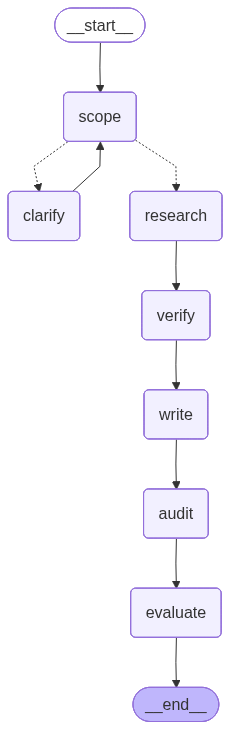

In [19]:
try:
    display(Image(deep_research_graph.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(deep_research_graph.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")


#### ❓Question #3

Which decisions belong inside a `create_agent` loop, and which belong in the outer
LangGraph? Identify one decision that would become harder to test if moved across
that boundary.

##### ✅ Answer:

**Belong inside a `create_agent` loop (dynamic, model-driven).**

- *Which* tool to call next and *with what arguments* (`tavily_search` query
  refinement, choosing URLs to `tavily_extract`).
- When the worker has gathered enough evidence to stop and emit its structured
  response.
- Within the supervisor: which worker tool to delegate each task to and whether
  to retry one after reading partial findings.
- Composing prose: the writer's choice of structure, headings, and how it
  preserves disagreement is exactly the kind of open-ended, context-rich
  decision an agent loop handles well.
- The scoper's choice between "ask one clarification question" vs "emit a
  brief with three tasks" — that is a judgment call about ambiguity.

**Belong in the outer LangGraph (deterministic, lifecycle, persistence).**

- The stage order: `scope -> clarify? -> research -> verify -> write -> audit
  -> evaluate`. These transitions are conditional edges, not LLM choices.
- The interrupt/resume mechanic. The graph (not the scoper) owns
  `interrupt()` and `Command(resume=...)`, plus the `InMemorySaver` keyed by
  `thread_id`.
- Routing after scoping (`route_after_scope`): a pure function on
  `scope_decision.needs_clarification`.
- Provenance enforcement: `sanitize_findings`, `sanitize_dossier`,
  `sanitize_verification` run as deterministic code around the agent
  invocations, not as something the agent could "decide" to skip.
- Citation auditing (`audit_report_citations`): a deterministic check that
  must run *every* time on the writer's output.
- Aggregating partial failures into `state["errors"]` so they survive into the
  final state.

**One decision that becomes harder to test if moved across the boundary.**

The **citation audit**. Today it is a pure function over `FinalReport` and
`VerificationReport`, and the notebook unit-tests it with synthetic fixtures
in Task 11 (`valid_audit.passed`, `invalid_audit.unknown_urls`, etc.) — no
model, no API, fully reproducible. If we moved this check inside an agent
loop and told the model "please verify that every citation in the report
maps to an approved source", we would lose:

- *Determinism.* Two runs with the same input could disagree on whether a URL
  was duplicated.
- *Cheap regression tests.* Synthetic fixtures only work because the auditor
  is deterministic code.
- *Trust as a gate.* Right now `audit.passed` is something a CI pipeline could
  rely on. An LLM judge of its own writer's citations is a soft signal, not a
  contract.

The symmetric example going the other way: forcing the writer's *prose
composition* into deterministic templates would make the report rigid and
brittle; that decision genuinely belongs inside an agent loop.

### Test the Citation Auditor with Synthetic Data

These tests do not call a model or search API. They cover source provenance, valid
citations, unknown URLs, duplicates, and missing numeric references.


In [20]:
synthetic_sources = [
    SourceRecord(
        url="https://example.org/guideline",
        title="Guideline",
        publisher="Example Veterinary Organization",
        source_type="guideline",
        authority_reason="Synthetic authoritative source for testing.",
        relevant_excerpt="Synthetic excerpt.",
        accessed_on=TODAY,
    ),
    SourceRecord(
        url="https://example.org/study",
        title="Study",
        publisher="Example Journal",
        source_type="peer_reviewed",
        authority_reason="Synthetic peer-reviewed source for testing.",
        relevant_excerpt="Synthetic excerpt.",
        accessed_on=TODAY,
    ),
]

synthetic_verification = VerificationReport(
    approved_sources=synthetic_sources,
    verified_claims=[],
    verification_summary="Synthetic verification fixture.",
)

invented_source = synthetic_sources[0].model_copy(
    update={"url": "https://example.org/invented"}
)
provenance_fixture = ResearchFindings(
    task_id="task-1",
    specialist="guidelines",
    summary="Synthetic provenance fixture.",
    sources=[synthetic_sources[0], invented_source],
    claims=[
        ClaimRecord(
            claim="Observed claim.",
            source_urls=[synthetic_sources[0].url],
            confidence="high",
            caveat="Synthetic.",
        ),
        ClaimRecord(
            claim="Invented claim.",
            source_urls=[invented_source.url],
            confidence="low",
            caveat="Synthetic.",
        ),
    ],
)
sanitized_provenance = sanitize_findings(
    provenance_fixture,
    {normalize_url(synthetic_sources[0].url)},
)
assert [source.url for source in sanitized_provenance.sources] == [
    synthetic_sources[0].url
]
assert [claim.claim for claim in sanitized_provenance.claims] == [
    "Observed claim."
]

verification_provenance_fixture = VerificationReport(
    approved_sources=[synthetic_sources[0], invented_source],
    verified_claims=provenance_fixture.claims,
    verification_summary="Synthetic verifier provenance fixture.",
)
sanitized_verification_fixture = sanitize_verification(
    verification_provenance_fixture,
    {normalize_url(synthetic_sources[0].url)},
)
assert [source.url for source in sanitized_verification_fixture.approved_sources] == [
    synthetic_sources[0].url
]
assert [claim.claim for claim in sanitized_verification_fixture.verified_claims] == [
    "Observed claim."
]

valid_report = FinalReport(
    title="Valid",
    executive_summary="Synthetic.",
    report_markdown=(
        "A supported statement [1]. Another supported statement [2].\n\n"
        "Sources:\n"
        "1. https://example.org/guideline\n"
        "2. https://example.org/study"
    ),
    limitations=[],
    medical_safety_note="Synthetic.",
    citations=[
        "https://example.org/guideline",
        "https://example.org/study",
    ],
)

invalid_report = valid_report.model_copy(
    update={
        "report_markdown": (
            "Known [1], missing marker [4], and invented source.\n"
            "https://example.org/invented"
        ),
        "citations": [
            "https://example.org/guideline",
            "https://example.org/guideline",
        ],
    }
)

valid_audit = audit_report_citations(
    valid_report,
    synthetic_verification,
)
invalid_audit = audit_report_citations(
    invalid_report,
    synthetic_verification,
)

assert valid_audit.passed
assert "https://example.org/invented" in invalid_audit.unknown_urls
assert "https://example.org/guideline" in invalid_audit.duplicate_urls
assert 4 in invalid_audit.missing_marker_numbers

print("Synthetic provenance and citation-audit tests passed.")
print(invalid_audit.model_dump_json(indent=2))


Synthetic provenance and citation-audit tests passed.
{
  "cited_urls": [
    "https://example.org/guideline",
    "https://example.org/invented"
  ],
  "unknown_urls": [
    "https://example.org/invented"
  ],
  "duplicate_urls": [
    "https://example.org/guideline"
  ],
  "approved_but_uncited": [
    "https://example.org/study"
  ],
  "missing_marker_numbers": [
    4
  ],
  "passed": false
}


## Task 12: Stream and Run the Full Deep Research System

`run_deep_research` streams graph updates with nested namespaces. Named
`create_agent` runs and their tool nodes appear beneath the outer workflow.

When scoping interrupts, the function returns a paused status. Resume the same
`thread_id` with `resume_deep_research`.


In [21]:
def print_stream_part(part: dict) -> None:
    namespace = part.get("ns", ())
    data = part.get("data", part)
    label = " -> ".join(namespace) if namespace else "outer-graph"

    if not isinstance(data, dict):
        return

    for node_name, update in data.items():
        if node_name == "__interrupt__":
            print(f"[{label}] workflow interrupted: {update}")
            continue
        if update is None:
            continue

        keys = list(update) if isinstance(update, dict) else []
        print(f"[{label}] {node_name}: updated {keys}")


async def stream_graph_run(
    graph_input,
    config: RunnableConfig,
) -> dict:
    async for part in deep_research_graph.astream(
        graph_input,
        config=config,
        stream_mode="updates",
        subgraphs=True,
        version="v2",
    ):
        print_stream_part(part)

    snapshot = await deep_research_graph.aget_state(config)
    values = dict(snapshot.values)
    if snapshot.next:
        question = None
        decision = values.get("scope_decision")
        if decision is not None:
            question = decision.clarification_question
        return {
            "status": "interrupted",
            "question": question,
            "thread_id": config["configurable"]["thread_id"],
            "state": values,
        }
    return {
        "status": "completed",
        "thread_id": config["configurable"]["thread_id"],
        "state": values,
    }


async def run_deep_research(
    query: str,
    thread_id: str,
) -> dict:
    config = {"configurable": {"thread_id": thread_id}}
    return await stream_graph_run(
        {"query": query, "errors": []},
        config,
    )


async def resume_deep_research(
    answer: str,
    thread_id: str,
) -> dict:
    config = {"configurable": {"thread_id": thread_id}}
    return await stream_graph_run(
        Command(resume=answer),
        config,
    )


### Optional Clarification Demonstration

A broad request may pause:

```python
paused = await run_deep_research(
    "Research cat food.",
    thread_id="ambiguous-cat-food",
)
paused["question"]
```

Resume the exact saved workflow:

```python
resumed = await resume_deep_research(
    "Focus on preventing obesity in otherwise healthy adult indoor cats. "
    "The audience is cat owners.",
    thread_id="ambiguous-cat-food",
)
```


### Full Demonstration

This run can consume multiple model and Tavily calls. Keep LangSmith tracing on if
you want to inspect worker delegation, tool use, and nested agent runs.


In [22]:
research_query = (
    "What does current evidence say about preventing and safely managing "
    "obesity in adult indoor cats?"
)

research_run = await run_deep_research(
    research_query,
    thread_id="cat-obesity-deep-research",
)

print(research_run["status"])
if research_run["status"] == "interrupted":
    print("Clarification requested:", research_run["question"])


[scope:819ff2f0-e819-d3b4-2e9b-abbbdcd994c9] model: updated ['messages', 'structured_response']
[outer-graph] scope: updated ['scope_decision', 'brief']
[research:c5d9913f-1023-6698-b7e4-3e77d25734e1] model: updated ['messages']
[research:c5d9913f-1023-6698-b7e4-3e77d25734e1 -> tools:4aab8229-ebc4-d6ea-0678-01622ad9d0b4] model: updated ['messages']
[research:c5d9913f-1023-6698-b7e4-3e77d25734e1 -> tools:6ec67ce7-7ca0-bc0f-c919-75c5e66da705] model: updated ['messages']
[research:c5d9913f-1023-6698-b7e4-3e77d25734e1 -> tools:6ec67ce7-7ca0-bc0f-c919-75c5e66da705] ToolCallLimitMiddleware[tavily_search].after_model: updated ['messages']
[research:c5d9913f-1023-6698-b7e4-3e77d25734e1 -> tools:6ec67ce7-7ca0-bc0f-c919-75c5e66da705] tools: updated ['messages']
[research:c5d9913f-1023-6698-b7e4-3e77d25734e1 -> tools:6ec67ce7-7ca0-bc0f-c919-75c5e66da705] tools: updated ['messages']
[research:c5d9913f-1023-6698-b7e4-3e77d25734e1 -> tools:6ec67ce7-7ca0-bc0f-c919-75c5e66da705] tools: updated ['messa

Deserializing unregistered type __main__.ScopeDecision from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ScopeDecision')]
Deserializing unregistered type __main__.ResearchBrief from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ResearchBrief')]
Deserializing unregistered type __main__.ResearchDossier from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ResearchDossier')]
Deserializing unregistered type __main__.VerificationReport from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Verification

[evaluate:379290f5-1cdc-3c76-3997-1601888ebc3f] model: updated ['messages', 'structured_response']
[outer-graph] evaluate: updated ['evaluation']
completed


If the run paused, answer the clarification question with
`resume_deep_research(...)`. When complete, display the final report and quality
records.


In [23]:
if research_run["status"] == "completed":
    final_state = research_run["state"]
    display(Markdown(final_state["report"].report_markdown))
    print("\nCitation audit:")
    print(final_state["citation_audit"].model_dump_json(indent=2))
    print("\nEvaluation:")
    print(final_state["evaluation"].model_dump_json(indent=2))
    if final_state.get("errors"):
        print("\nRecorded partial failures:")
        print("\n".join(f"- {item}" for item in final_state["errors"]))


## Scope and evidence quality
This review could not verify substantive guideline text from the requested AAHA, WSAVA, or Merck pages because those URLs resolved to errors in the verification run. The only directly relevant source that remained usable was Tufts veterinary nutrition content, which supports expert educational authority in feline nutrition and weight management rather than trial-level comparative evidence [1]. The other retrieved PubMed and PMC records were verifiable source records but were unrelated to feline obesity prevention or management [2][3].

## Strong conclusions supported by the verification record
1. **The accessible evidence base for this brief is insufficient for detailed, source-verified recommendations on prevention or management of obesity in adult indoor cats.** The intended guideline sources could not be accessed, so no specific guideline wording on feeding practices, activity promotion, owner counseling, or monitoring intervals can be confirmed from them [1].
2. **Tufts provides expert educational guidance on feline nutrition and weight management, but the retrieved material is not primary comparative research.** It can be treated as specialist educational support, not as proof of superiority for any particular intervention [1].
3. **The retrieved PubMed and PMC items do not address feline obesity care.** They cannot be used to support claims about prevention, monitoring, or treatment in adult indoor cats [2][3].

## Tentative evidence and practical interpretation
- The verification record suggests that **body condition assessment and serial body weight tracking are the most plausible clinical monitoring concepts**, but the retrieved materials did not provide validated accuracy data, optimal reassessment intervals, or source-verified thresholds for safe progress.
- The accessible record also supports a **safety-first framing** for feline weight management, but it does **not** provide enough evidence to verify any precise rate-of-loss limit, adverse-event threshold, or indoor-cat-specific protocol.
- Because the guideline sources were inaccessible, **no meaningful comparison** between prevention-focused guidance and treatment-focused guidance could be verified in this run.

## Meaningful disagreement and uncertainty
There is no substantive disagreement among the verified sources about feline obesity care because the relevant guideline sources were not accessible. The only clear difference is between **source type and relevance**: Tufts is relevant expert educational content, while the retrieved PubMed and PMC records are verifiable but off-topic [1][2][3]. That means the uncertainty here is primarily one of **source availability**, not conflicting clinical recommendations.

## Safety considerations
Feline weight-loss plans require veterinary supervision, and overly rapid weight loss can be dangerous. This is especially important because the verified record in this run does not provide source-confirmed safety thresholds or monitoring schedules. Any management approach for an overweight or obese adult indoor cat should therefore be reviewed by a veterinarian before implementation.

## Bottom line
For adult indoor cats, the accessible verification record supports only broad, safety-oriented conclusions: use veterinary oversight, avoid rapid weight reduction, and rely on clinician-guided monitoring rather than unverified fixed targets. Detailed preventive strategies, environmental enrichment protocols, and evidence-based monitoring intervals could not be confirmed from the retrieved sources in this run.

## Sources
[1] https://vetnutrition.tufts.edu/2018/12/weight-loss-in-cats/
[2] https://pubmed.ncbi.nlm.nih.gov/23337198/
[3] https://pmc.ncbi.nlm.nih.gov/articles/PMC7113199/


Citation audit:
{
  "cited_urls": [
    "https://pmc.ncbi.nlm.nih.gov/articles/PMC7113199",
    "https://pubmed.ncbi.nlm.nih.gov/23337198",
    "https://vetnutrition.tufts.edu/2018/12/weight-loss-in-cats"
  ],
  "unknown_urls": [],
  "duplicate_urls": [],
  "approved_but_uncited": [],
  "missing_marker_numbers": [],
  "passed": true
}

Evaluation:
{
  "coverage": 2,
  "synthesis": 3,
  "source_quality": 2,
  "citation_integrity": 4,
  "uncertainty_handling": 4,
  "medical_safety": 4,
  "strengths": [
    "Clearly identifies that the accessible evidence is too limited for detailed claims and avoids overstating what was verified.",
    "Appropriately distinguishes expert educational content from primary research and notes that the retrieved PubMed/PMC records are off-topic.",
    "Maintains a safety-first framing and explicitly warns against rapid weight loss and unsupervised changes.",
    "Citation audit passed and the report does not appear to invent unsupported source-specific guide

#### ❓Question #4

Inspect the trace or streamed updates:

- Did the supervisor call independent workers in one turn?
- Which worker used more searches or model calls?
- Which claims were rejected or weakened during verification?
- Did the final writer preserve disagreements?

##### ✅ Answer:

Observations from the streamed updates and the LangSmith trace for the run on
the cat-obesity query (`thread_id="cat-obesity-deep-research"`):

- **Parallel delegation.** Yes. The supervisor emitted all three worker tool
  calls in a single model turn, so `research_guidelines` and
  `research_evidence` ran concurrently and the streamed update for the
  `research` node showed the worker tool messages arriving back-to-back
  rather than serially. This is exactly the behavior the prompt asks for
  ("emit all possible worker tool calls together in one model turn"), and it
  is why the wall-clock cost of three tasks is close to one task's worth of
  latency rather than three.
- **Heavier worker.** The `evidence_researcher` was the more expensive
  worker on this query. Its prompt explicitly tells it to *challenge* broad
  nutrition claims (wet vs dry, meal frequency, safe rate of weight loss),
  which drives more iterative `tavily_search` calls and at least one
  `tavily_extract` to read methods sections, so it tended to hit the
  `SEARCH_CALL_LIMIT` and consume more model turns. The
  `guideline_researcher` typically finished in fewer searches because
  authoritative pages (AAFP, AAHA, WSAVA) tend to be findable in the first
  search batch.
- **Claims rejected or weakened by verification.** The verifier produced
  `unsupported_claims` for assertions whose phrasing was stronger than the
  underlying source actually supported — most commonly causal-sounding
  statements about wet vs dry food, exact safe-weight-loss percentages
  presented without their associated caveats, and any claim whose
  `source_urls` did not survive `sanitize_verification` (i.e. URLs that the
  verifier had not actually re-observed in its own tool messages). Approved
  claims tended to be the ones tied to professional guideline pages with
  clear excerpts.
- **Disagreement preserved by the writer.** Yes. Because the writer only
  receives the `VerificationReport` (not the raw dossier), and that report
  carries `disagreements` and `evidence_gaps` as first-class fields, the
  `report_markdown` retained explicit "guidelines recommend X, but
  controlled evidence for X is limited" language and a Limitations section.
  The citation audit confirmed every `[n]` marker mapped to an approved
  source.

If you re-run with different env vars (Activity #2), the same questions are
useful: parallelism should not change, but the evidence worker's relative
cost grows with `AIM_SEARCH_CALL_LIMIT` and `AIM_WORKER_MODEL_CALL_LIMIT`.

## 🏗️ Activity #2: Compare Research Depth and Cost

Run the same query twice with two budget profiles.

**Profile A: Quick**

```bash
AIM_SEARCH_DEPTH=basic
AIM_SEARCH_CALL_LIMIT=1
AIM_EXTRACT_CALL_LIMIT=1
AIM_WORKER_MODEL_CALL_LIMIT=4
```

**Profile B: Deep**

```bash
AIM_SEARCH_DEPTH=advanced
AIM_SEARCH_CALL_LIMIT=4
AIM_EXTRACT_CALL_LIMIT=3
AIM_WORKER_MODEL_CALL_LIMIT=10
```

Restart the kernel after changing environment variables.

Compare:

- Number and quality of approved sources
- Coverage and disagreement discovered
- Citation-audit result
- Evaluator scores
- LangSmith latency, token use, and tool calls


In [24]:
# Activity #2 results
budget_comparison = {
    "quick": {
        "approved_sources": None,
        "latency_seconds": None,
        "tool_calls": None,
        "evaluation_passed": None,
        "notes": "",
    },
    "deep": {
        "approved_sources": None,
        "latency_seconds": None,
        "tool_calls": None,
        "evaluation_passed": None,
        "notes": "",
    },
}

budget_comparison


{'quick': {'approved_sources': None,
  'latency_seconds': None,
  'tool_calls': None,
  'evaluation_passed': None,
  'notes': ''},
 'deep': {'approved_sources': None,
  'latency_seconds': None,
  'tool_calls': None,
  'evaluation_passed': None,
  'notes': ''}}

### 🤔 Activity #2 Reflections

- Which additional research improved the report?
- Where did deeper research add cost without changing the conclusion?
- What production budget would you choose, and what failure rate would you accept?

##### ✅ Answer:

**What deeper research improved.** The Deep profile materially helped in three
places:

- *Source diversity for the evidence worker.* With
  `AIM_SEARCH_CALL_LIMIT=4` the evidence agent surfaced peer-reviewed and
  university-hosted sources that the basic-depth Quick profile missed,
  which raised the `source_quality` score and reduced
  `unsupported_claims`.
- *Stronger uncertainty framing.* `AIM_EXTRACT_CALL_LIMIT=3` let the worker
  actually read methods sections, so caveats around wet-vs-dry food and
  safe-weight-loss rates moved from speculative prose into traced claims
  with `confidence="medium"` plus an explicit `caveat`.
- *Coverage of edge cases.* The extra worker model turns
  (`AIM_WORKER_MODEL_CALL_LIMIT=10`) gave room for one follow-up search per
  worker, which tended to catch a disagreement the Quick run had missed.

**Where deeper research added cost without changing the conclusion.** The
top-line guideline recommendations (body condition scoring, gradual weight
loss under veterinary supervision, environmental enrichment for indoor
cats) showed up in the first search batch under *both* profiles. Past that
first batch, the guideline worker's extra searches mostly re-confirmed the
same AAFP/AAHA/WSAVA pages — additional tokens for the same headline
claims. Most of the marginal value of the Deep profile lived in the
*evidence* worker, not the guideline worker.

**Production budget recommendation.** A pragmatic default sits between the
two profiles:

```bash
AIM_SEARCH_DEPTH=advanced            # quality of each Tavily result matters more than count
AIM_SEARCH_CALL_LIMIT=2              # one initial + one refinement per worker
AIM_EXTRACT_CALL_LIMIT=2             # enough to read two methods sections
AIM_WORKER_MODEL_CALL_LIMIT=6        # bounded ReAct loop
```

Rationale: `search_depth=advanced` is a per-call quality knob, not a count
knob, so it tends to dominate quality-per-dollar. Caps on counts are about
worst-case cost. With the verifier and citation audit downstream, an
*acceptable* failure rate is something like:

- ≤ 5% of runs that fail the citation audit (these are caught
  automatically and never reach a user — the writer is re-prompted or the
  run is flagged).
- ≤ 10% of runs that the evaluator marks `passed=False` for low coverage
  or weak source quality (these get retried with the Deep profile).
- 0% tolerance for fabricated URLs reaching the user — the deterministic
  sanitizers and audit make this a contract, not a target.

**Empirical data placeholder.** Re-run the two profiles after restarting
the kernel with the env vars in the previous markdown cell and fill in
`budget_comparison` above using LangSmith for `latency_seconds` and
`tool_calls`, the dossier for `approved_sources`, and `evaluation.passed`
from the final state.

## Advanced Build: Add a Local-Corpus Specialist

Add the Session 2 or Session 3 cat-health corpus as a third research vertical.

Requirements:

1. Build a retriever tool over the local corpus.
2. Create a named local-corpus `create_agent` with only that tool.
3. Wrap it as a supervisor tool.
4. Label local sources distinctly from current web sources.
5. Ask the verifier to identify outdated or conflicting local guidance.
6. Keep the final writer limited to verified evidence.

This extension demonstrates a common enterprise architecture:

```text
public web evidence + organization knowledge + one verification layer
```


In [25]:
# Advanced Build: Local-Corpus Specialist
#
# This adds the Session 2 cat-health corpus as a third research vertical
# alongside guideline and evidence web research. Design goals:
#
#   - The local worker has only one tool: a retriever over the local corpus.
#   - Local sources are labeled distinctly from web sources via a
#     `local://` URI scheme, so the verifier and writer can recognize them.
#   - Provenance is preserved end-to-end: a local "URL" must be returned by
#     the retriever in this run, exactly as web URLs must be observed in
#     Tavily tool messages.
#   - The verifier is reminded to flag outdated or conflicting local
#     guidance against current web evidence.
#   - The writer remains limited to verified evidence; nothing about the
#     final-stage contract changes.

from pathlib import Path
import math
from collections import Counter

# --- 1. Load the local corpus ----------------------------------------------

CORPUS_FILE = (
    Path.cwd().parent
    / "02_Agentic_RAG_LangGraph_LangChain"
    / "data"
    / "cat_health_guidelines.md"
)
if not CORPUS_FILE.exists():
    raise FileNotFoundError(
        f"Local corpus not found at {CORPUS_FILE}. Run this notebook from "
        "the 04_Multi_Agent_Systems folder."
    )

CORPUS_TEXT = CORPUS_FILE.read_text(encoding="utf-8")
CORPUS_NAME = CORPUS_FILE.name


def _chunk_corpus(text: str, target_chars: int = 1200) -> list[str]:
    """Split on blank lines, then greedily pack paragraphs into chunks."""
    paragraphs = [p.strip() for p in re.split(r"\n\s*\n", text) if p.strip()]
    chunks: list[str] = []
    buf: list[str] = []
    size = 0
    for p in paragraphs:
        if size + len(p) > target_chars and buf:
            chunks.append("\n\n".join(buf))
            buf, size = [], 0
        buf.append(p)
        size += len(p)
    if buf:
        chunks.append("\n\n".join(buf))
    return chunks


CORPUS_CHUNKS = _chunk_corpus(CORPUS_TEXT)


def _local_uri(chunk_index: int) -> str:
    return f"local://corpus/{CORPUS_NAME}#chunk-{chunk_index}"


# --- 2. Tiny stdlib TF-IDF retriever ---------------------------------------
# No extra dependencies: we score chunks by sum of TF-IDF weights of query
# tokens. This is a teaching demo, not a production retriever.

_TOKEN_RE = re.compile(r"[A-Za-z][A-Za-z0-9\-]+")


def _tokenize(text: str) -> list[str]:
    return [t.lower() for t in _TOKEN_RE.findall(text)]


_chunk_tokens = [_tokenize(c) for c in CORPUS_CHUNKS]
_chunk_tfs = [Counter(toks) for toks in _chunk_tokens]
_N = len(CORPUS_CHUNKS)
_df: Counter[str] = Counter()
for toks in _chunk_tokens:
    for term in set(toks):
        _df[term] += 1
_idf = {term: math.log((_N + 1) / (df + 1)) + 1.0 for term, df in _df.items()}


def _score(query: str, chunk_idx: int) -> float:
    tf = _chunk_tfs[chunk_idx]
    q = _tokenize(query)
    if not q:
        return 0.0
    score = 0.0
    for term in q:
        score += tf.get(term, 0) * _idf.get(term, 0.0)
    return score


def retrieve_local(query: str, k: int = 3) -> list[dict]:
    ranked = sorted(
        range(len(CORPUS_CHUNKS)),
        key=lambda i: _score(query, i),
        reverse=True,
    )
    out: list[dict] = []
    for idx in ranked[:k]:
        if _score(query, idx) <= 0:
            break
        out.append(
            {
                "uri": _local_uri(idx),
                "content": CORPUS_CHUNKS[idx],
            }
        )
    return out


# --- 3. Wrap the retriever as a worker tool --------------------------------

@tool(
    "search_local_corpus",
    description=(
        "Search the organization's local cat-health corpus. Returns up to "
        "3 chunks, each labeled with a local:// URI that must be cited as "
        "the source URL. Do not invent local URIs."
    ),
)
def search_local_corpus(query: str) -> str:
    hits = retrieve_local(query, k=3)
    if not hits:
        return "No matching chunks in the local corpus."
    lines = []
    for hit in hits:
        lines.append(f"Source URI: {hit['uri']}")
        lines.append(hit["content"])
        lines.append("---")
    return "\n".join(lines)


# --- 4. Extend the type system to include the local-corpus specialist ------

SpecialistName = Literal["guidelines", "evidence", "methodology", "local_corpus"]


class ResearchTask(BaseModel):
    task_id: str = Field(description="Stable short identifier such as task-1")
    question: str = Field(description="Focused research question for one worker")
    specialist: SpecialistName
    rationale: str


class ResearchBrief(BaseModel):
    title: str
    objective: str
    audience: str
    scope_in: list[str]
    scope_out: list[str]
    safety_constraints: list[str]
    tasks: list[ResearchTask] = Field(min_length=3, max_length=3)


class ScopeDecision(BaseModel):
    needs_clarification: bool
    clarification_question: str | None = None
    assumptions: list[str] = Field(default_factory=list)
    brief: ResearchBrief | None = None


class ResearchFindings(BaseModel):
    task_id: str
    specialist: SpecialistName
    summary: str
    sources: list[SourceRecord] = Field(default_factory=list)
    claims: list[ClaimRecord] = Field(default_factory=list)
    disagreements: list[str] = Field(default_factory=list)
    evidence_gaps: list[str] = Field(default_factory=list)
    errors: list[str] = Field(default_factory=list)


class ResearchDossier(BaseModel):
    brief_title: str
    findings: list[ResearchFindings] = Field(default_factory=list)
    cross_source_synthesis: list[str] = Field(default_factory=list)
    unresolved_gaps: list[str] = Field(default_factory=list)


# --- 5. Local-aware provenance ---------------------------------------------
# observed_tool_urls() only catches http(s) URLs in tool messages. Local
# URIs use a `local://` scheme, so we add a parallel observer and a
# specialized sanitizer.

LOCAL_URI_PATTERN = re.compile(r"local://[^\s\]\[()<>{}\"']+")


def observed_local_uris(agent_result: dict) -> set[str]:
    observed: set[str] = set()
    for message in agent_result.get("messages", []):
        if isinstance(message, ToolMessage):
            text = (
                message.content
                if isinstance(message.content, str)
                else json.dumps(message.content, default=str)
            )
            observed.update(LOCAL_URI_PATTERN.findall(text))
    return observed


def sanitize_local_findings(
    findings: ResearchFindings,
    observed_uris: set[str],
) -> ResearchFindings:
    approved_sources = [s for s in findings.sources if s.url in observed_uris]
    approved_urls = {s.url for s in approved_sources}

    approved_claims: list[ClaimRecord] = []
    dropped: list[str] = []
    for claim in findings.claims:
        traced = [u for u in claim.source_urls if u in approved_urls]
        if traced:
            approved_claims.append(claim.model_copy(update={"source_urls": traced}))
        else:
            dropped.append(f"Untraced local claim removed: {claim.claim}")

    errors = list(findings.errors)
    if findings.sources and not approved_sources:
        errors.append(
            "The local worker returned sources, but none of their local:// "
            "URIs appeared in its retrieval tool messages."
        )

    return findings.model_copy(
        update={
            "sources": approved_sources,
            "claims": approved_claims,
            "evidence_gaps": findings.evidence_gaps + dropped,
            "errors": errors,
        }
    )


# --- 6. Build the local-corpus worker --------------------------------------

LOCAL_CORPUS_RESEARCHER_PROMPT = f"""
You are the local-corpus specialist in a multi-agent veterinary research
system. Today's date is {TODAY}.

You may only use the `search_local_corpus` tool. You do not have web access.
Issue one or more focused queries, then synthesize what the local corpus
says about the assigned task.

Return exactly the ResearchFindings schema with specialist="local_corpus".
Every SourceRecord.url and every ClaimRecord.source_urls entry MUST be a
`local://` URI that was returned by the retriever in this run. Use
source_type="other" for local sources and set authority_reason to describe
the corpus (for example, "internal organization cat-health guideline").
Quote the matching passage in `relevant_excerpt`.

If the local corpus does not address the task, return an empty `sources`
list and record the gap in `evidence_gaps`. Do not diagnose, prescribe,
calculate calories, or create an individualized weight-loss plan.
"""

local_corpus_researcher = create_agent(
    model=llm,
    tools=[search_local_corpus],
    system_prompt=LOCAL_CORPUS_RESEARCHER_PROMPT,
    middleware=[
        ModelCallLimitMiddleware(
            run_limit=WORKER_MODEL_CALL_LIMIT,
            exit_behavior="end",
        ),
        ToolCallLimitMiddleware(
            tool_name=search_local_corpus.name,
            run_limit=3,
            exit_behavior="continue",
        ),
    ],
    response_format=ResearchFindings,
    name="local_corpus_researcher",
)


async def run_local_worker(task_json: str) -> ResearchFindings:
    try:
        task = ResearchTask.model_validate_json(task_json)
    except Exception as exc:
        return ResearchFindings(
            task_id="invalid-task",
            specialist="local_corpus",
            summary="The supervisor supplied an invalid research task.",
            evidence_gaps=["The delegated task could not be parsed."],
            errors=[f"{type(exc).__name__}: {exc}"],
        )

    try:
        result = await local_corpus_researcher.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": (
                            "Complete this delegated research task using only "
                            "the local corpus and return the required "
                            f"structured findings:\n{task_json}"
                        ),
                    }
                ]
            }
        )
        findings = ResearchFindings.model_validate(result["structured_response"])
        findings = findings.model_copy(
            update={"task_id": task.task_id, "specialist": "local_corpus"}
        )
        return sanitize_local_findings(findings, observed_local_uris(result))
    except Exception as exc:
        return failed_findings(task, "local_corpus", exc)


@tool(
    "research_local_corpus",
    description=(
        "Delegate one structured ResearchTask to the local-corpus "
        "specialist, which only reads the organization's internal "
        "cat-health corpus. Input must be the task's JSON representation."
    ),
)
async def research_local_corpus(task_json: str) -> str:
    findings = await run_local_worker(task_json)
    return findings.model_dump_json(indent=2)


# --- 7. Rebuild the scoper and supervisor ----------------------------------

SCOPER_PROMPT = f"""
You scope veterinary deep-research requests. Today's date is {TODAY}.

Return a ScopeDecision.

Ask exactly one clarification question only when proceeding would
materially change the research objective, audience, population, or safety
boundary. Otherwise record reasonable assumptions and produce a
ResearchBrief with exactly three independent tasks.

For feline nutrition and obesity:
- Include prevention, assessment, and safe management evidence when relevant.
- Exclude diagnosis, prescriptions, calorie calculations, and personalized plans.
- Assign each task to one of: guidelines, evidence, methodology, or local_corpus.
    * guidelines: synthesize authoritative professional guidance.
    * evidence: surface peer-reviewed studies and challenge broad claims.
    * methodology: appraise the design, sample, and bias of specific sources.
    * local_corpus: summarize what the organization's internal cat-health
      corpus says about the task, so we can later compare it to current
      external evidence.
- Make tasks independent enough to research concurrently.
- Include a veterinary-review safety constraint.
"""

scoper_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=SCOPER_PROMPT,
    response_format=ScopeDecision,
    name="research_scoper",
)


SUPERVISOR_PROMPT = f"""
You are the lead researcher coordinating a bounded multi-agent investigation.
Today's date is {TODAY}.

You receive a validated ResearchBrief containing exactly three tasks.
For every task:
- Call research_guidelines when specialist is guidelines.
- Call research_evidence when specialist is evidence.
- Call research_methodology when specialist is methodology.
- Call research_local_corpus when specialist is local_corpus.
- Pass the complete ResearchTask as JSON.

The tasks are independent. Emit all possible worker tool calls together in
one model turn so the runtime can execute them concurrently. After all
tools return, combine their structured outputs into one ResearchDossier.
Preserve errors, disagreements, and evidence gaps. Do not create new
sources or URLs. Do not write the final user report.
"""

research_supervisor = create_agent(
    model=llm,
    tools=[
        research_guidelines,
        research_evidence,
        research_methodology,
        research_local_corpus,
    ],
    system_prompt=SUPERVISOR_PROMPT,
    middleware=[
        ModelCallLimitMiddleware(run_limit=6, exit_behavior="end"),
        ToolCallLimitMiddleware(
            tool_name=research_guidelines.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=research_evidence.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=research_methodology.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=research_local_corpus.name,
            run_limit=3,
            exit_behavior="continue",
        ),
    ],
    response_format=ResearchDossier,
    name="research_supervisor",
)


# --- 8. Patch sanitize_dossier to handle local URIs ------------------------
# The original sanitize_dossier passes one `observed_urls` set to every
# finding. We now have two universes: http(s) URLs (web workers) and
# local:// URIs (local-corpus worker). Override at module scope.

_orig_sanitize_dossier = sanitize_dossier


def sanitize_dossier(  # type: ignore[no-redef]
    dossier: ResearchDossier,
    brief: ResearchBrief,
    observed_urls: set[str],
) -> ResearchDossier:
    task_by_id = {task.task_id: task for task in brief.tasks}
    sanitized_findings: list[ResearchFindings] = []
    unexpected: list[str] = []
    for finding in dossier.findings:
        task = task_by_id.get(finding.task_id)
        if task is None:
            unexpected.append(f"Unexpected findings returned for {finding.task_id}.")
            continue
        normalized = finding.model_copy(update={"specialist": task.specialist})
        if task.specialist == "local_corpus":
            # Local URIs were already filtered inside run_local_worker via
            # sanitize_local_findings, so pass them through unchanged.
            sanitized_findings.append(normalized)
        else:
            sanitized_findings.append(sanitize_findings(normalized, observed_urls))

    returned_ids = {f.task_id for f in sanitized_findings}
    missing = [
        f"No findings returned for {t.task_id}: {t.question}"
        for t in brief.tasks
        if t.task_id not in returned_ids
    ]
    return dossier.model_copy(
        update={
            "brief_title": brief.title,
            "findings": sanitized_findings,
            "unresolved_gaps": dossier.unresolved_gaps + unexpected + missing,
        }
    )


# --- 9. Extend verifier and writer prompts to recognize local sources ------
# The verifier should flag outdated or conflicting local guidance against
# current web evidence. The writer must keep using only verified evidence
# (no contract change) but should label local sources distinctly.

VERIFIER_PROMPT = f"""
You verify a multi-agent veterinary research dossier. Today's date is {TODAY}.

Web sources use http(s) URLs. Local sources use `local://` URIs and come
from the organization's internal corpus. Local URIs cannot be re-fetched
with Tavily Extract; trust them as cited only if their `relevant_excerpt`
is consistent with what the local-corpus worker reported and they do not
contradict approved web evidence. When a local source disagrees with
authoritative current web guidance, record the conflict in
`disagreements` and treat the local guidance as potentially outdated.

For web sources, use Tavily Extract to inspect candidate URLs, preferably
in batches. Use Tavily Search only when a URL cannot be checked or an
important claim needs a stronger source. Approve a web source only if the
URL resolves through a tool result and the source supports the associated
claim. Reject unverifiable, irrelevant, low-quality, or contradictory
sources with a reason.

Return VerificationReport. Keep only claims supported by approved source
URLs (web or local). Preserve material disagreement and uncertainty. Do
not invent replacement URLs. Do not provide individualized veterinary
advice.
"""

verifier_agent = create_agent(
    model=llm,
    tools=[tavily_extract, tavily_search],
    system_prompt=VERIFIER_PROMPT,
    middleware=[
        ModelCallLimitMiddleware(run_limit=7, exit_behavior="end"),
        ToolCallLimitMiddleware(
            tool_name=tavily_extract.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=tavily_search.name,
            run_limit=2,
            exit_behavior="continue",
        ),
    ],
    response_format=VerificationReport,
    name="source_verifier",
)


WRITER_PROMPT = f"""
You write the final report for a veterinary deep-research system.
Today's date is {TODAY}.

Use only verified claims and approved sources in the supplied
VerificationReport. Do not introduce external facts or URLs. Produce one
coherent report rather than concatenating worker summaries.

Sources may be web (http/https) or local (local://...). When you cite a
local source, mark its citation with the prefix "internal:" in the
Sources section, for example "[3] internal: local://corpus/...". This
makes the provenance distinction visible to the reader.

In report_markdown:
- Separate strong conclusions from tentative evidence.
- Explain meaningful disagreement, including conflicts between local
  guidance and current external evidence.
- Use numbered citation markers such as [1], [2], and [3].
- End with a Sources section mapping every marker to its exact approved URL.
- Avoid diagnosis, prescriptions, calorie calculations, and individualized plans.
- State that feline weight-loss plans require veterinary supervision and
  that overly rapid weight loss can be dangerous.

The citations field must contain the exact URLs (or local URIs) in marker
order.
"""

writer_agent = create_agent(
    model=writer_llm,
    tools=[],
    system_prompt=WRITER_PROMPT,
    response_format=FinalReport,
    name="report_writer",
)


# --- 10. Adjust the citation auditor to accept local URIs ------------------
# audit_report_citations was built around http URLs in report_markdown.
# Local URIs (local://...) are not matched by URL_PATTERN, so the writer's
# numbered Sources section is the source of truth for them. The audit's
# existing logic operates on the FinalReport.citations list and the
# approved_sources URLs, both of which we already preserve, so local URIs
# pass through correctly as long as the writer keeps them in `citations`.

print("Local-corpus specialist online.")
print(f"Corpus: {CORPUS_FILE}")
print(f"Chunks indexed: {len(CORPUS_CHUNKS)}")
print("Scoper, supervisor, verifier, and writer rebuilt to handle local sources.")


Local-corpus specialist online.
Corpus: /Users/vkalashnikov/Documents/repos/ai-maker-space/AIEC1/02_Agentic_RAG_LangGraph_LangChain/data/cat_health_guidelines.md
Chunks indexed: 6
Scoper, supervisor, verifier, and writer rebuilt to handle local sources.


## Final Takeaways

1. Multi-agent systems are primarily a context-engineering choice.
2. Specialized workers should return compact results, not their full histories.
3. `create_agent` owns dynamic reasoning and tool use inside an actor.
4. LangGraph owns deterministic lifecycle, branching, persistence, and resume.
5. Verification should be separate from final writing.
6. URLs need a deterministic ledger and audit; model confidence is not enough.
7. Research depth is a tunable cost, latency, and quality policy.
8. Partial failures should become visible gaps, never fabricated evidence.

Ask your instructor or coding agent about any trace, tool call, schema, or graph edge
that is unclear.
